(ch_clustering_2)=
# Clustering beyond the basics

In the previous chapter, we introduced clustering as the task of grouping similar data points and looked at two important approaches: **K-means**, which represents clusters by their centers, and **DBSCAN**, which defines clusters through dense regions of points. These two methods already illustrate an important lesson: different clustering algorithms come with different ideas of what a cluster is.

In this chapter, we go a step further. We will look at two additional and very important clustering approaches:

* **Gaussian Mixture Models (GMMs)**, which allow for *soft clustering* and can model more flexible cluster shapes than K-means.
* **Hierarchical clustering**, which does not just produce one final partition of the data, but a whole hierarchy of nested groupings.

At the end, we will compare the different clustering approaches more directly and summarize when each of them tends to work well.

## Gaussian Mixture Models

Gaussian Mixture Models, usually abbreviated as **GMMs**, are a more flexible and probabilistic approach to clustering. If K-means imagines each cluster as a group around a center point, then GMM imagines the data as having been generated from a mixture of several overlapping probability distributions.

More specifically, GMM assumes that the data points come from a combination of several **Gaussian distributions**. Each Gaussian distribution corresponds to one cluster and is described by parameters such as:

* a **mean** (the center of the cluster),
* a **covariance matrix** (which describes the spread and orientation of the cluster),
* and a **weight** (which reflects how much this component contributes to the full dataset).

This makes GMM more flexible than K-means. K-means effectively prefers roughly spherical clusters of similar spread, while GMM can model elongated, tilted, and differently shaped clusters.

## Soft clustering

A particularly important feature of GMM is that it performs **soft clustering**.

K-means assigns every point to exactly one cluster. GMM, by contrast, assigns each point a **probability of belonging to each cluster**. A point near the center of one Gaussian may have a very high probability for that cluster and very low probabilities for all others. A point located between two clusters may have a more mixed assignment.

This is often useful in practice, because real data does not always contain perfectly separated groups. Sometimes the boundaries between groups are fuzzy, and it is more honest to reflect this uncertainty directly.

### How GMM works

The standard way to fit a Gaussian mixture model is the **Expectation-Maximization (EM)** algorithm.

In simplified form, the process looks like this:

1. **Initialization**  
   We start with an initial guess for the Gaussian components: their means, covariances, and weights.

2. **Expectation step (E-step)**  
   For each data point, the algorithm estimates the probability that it belongs to each Gaussian component.

3. **Maximization step (M-step)**  
   Using these probabilities, the algorithm updates the Gaussian parameters so that the model better fits the data.

4. **Repeat**  
   The E-step and M-step are repeated until the parameter changes become small enough.

So, unlike K-means, which alternates between hard assignment and centroid update, GMM alternates between probabilistic assignment and parameter update.

## GMM on our toy dataset

Let us again use the same five-cluster toy dataset from the previous chapter.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# optional, only to avoid KMeans warning on Windows (too few chunks compared to threads)
import os
os.environ["OMP_NUM_THREADS"] = "1"

# Set the ggplot style (optional)
plt.style.use("ggplot")

In [2]:
clusters = [(61, 1, 1.5, 2.5, -0.7),
           (37, 0.8, 0.5, 1.1, -1.2),
           (49, 1.1, 1.2, -2.6, 2.3),
           (44, 0.45, 0.4, 0.5, 2.3),
           (70, 0.9, 0.3, -2.5, -1.7)]

np.random.seed(1)
data = np.zeros((0, 2))
for (n_points, x_scale, y_scale, x_offset, y_offset) in clusters:
    xpts = np.random.randn(n_points) * x_scale + x_offset
    ypts = np.random.randn(n_points) * y_scale + y_offset
    data = np.vstack((data, np.vstack((xpts, ypts)).T))

In [3]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=5, random_state=0).fit(data)
labels = gm.predict(data)

C:\Users\flori\anaconda3\envs\data_science\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


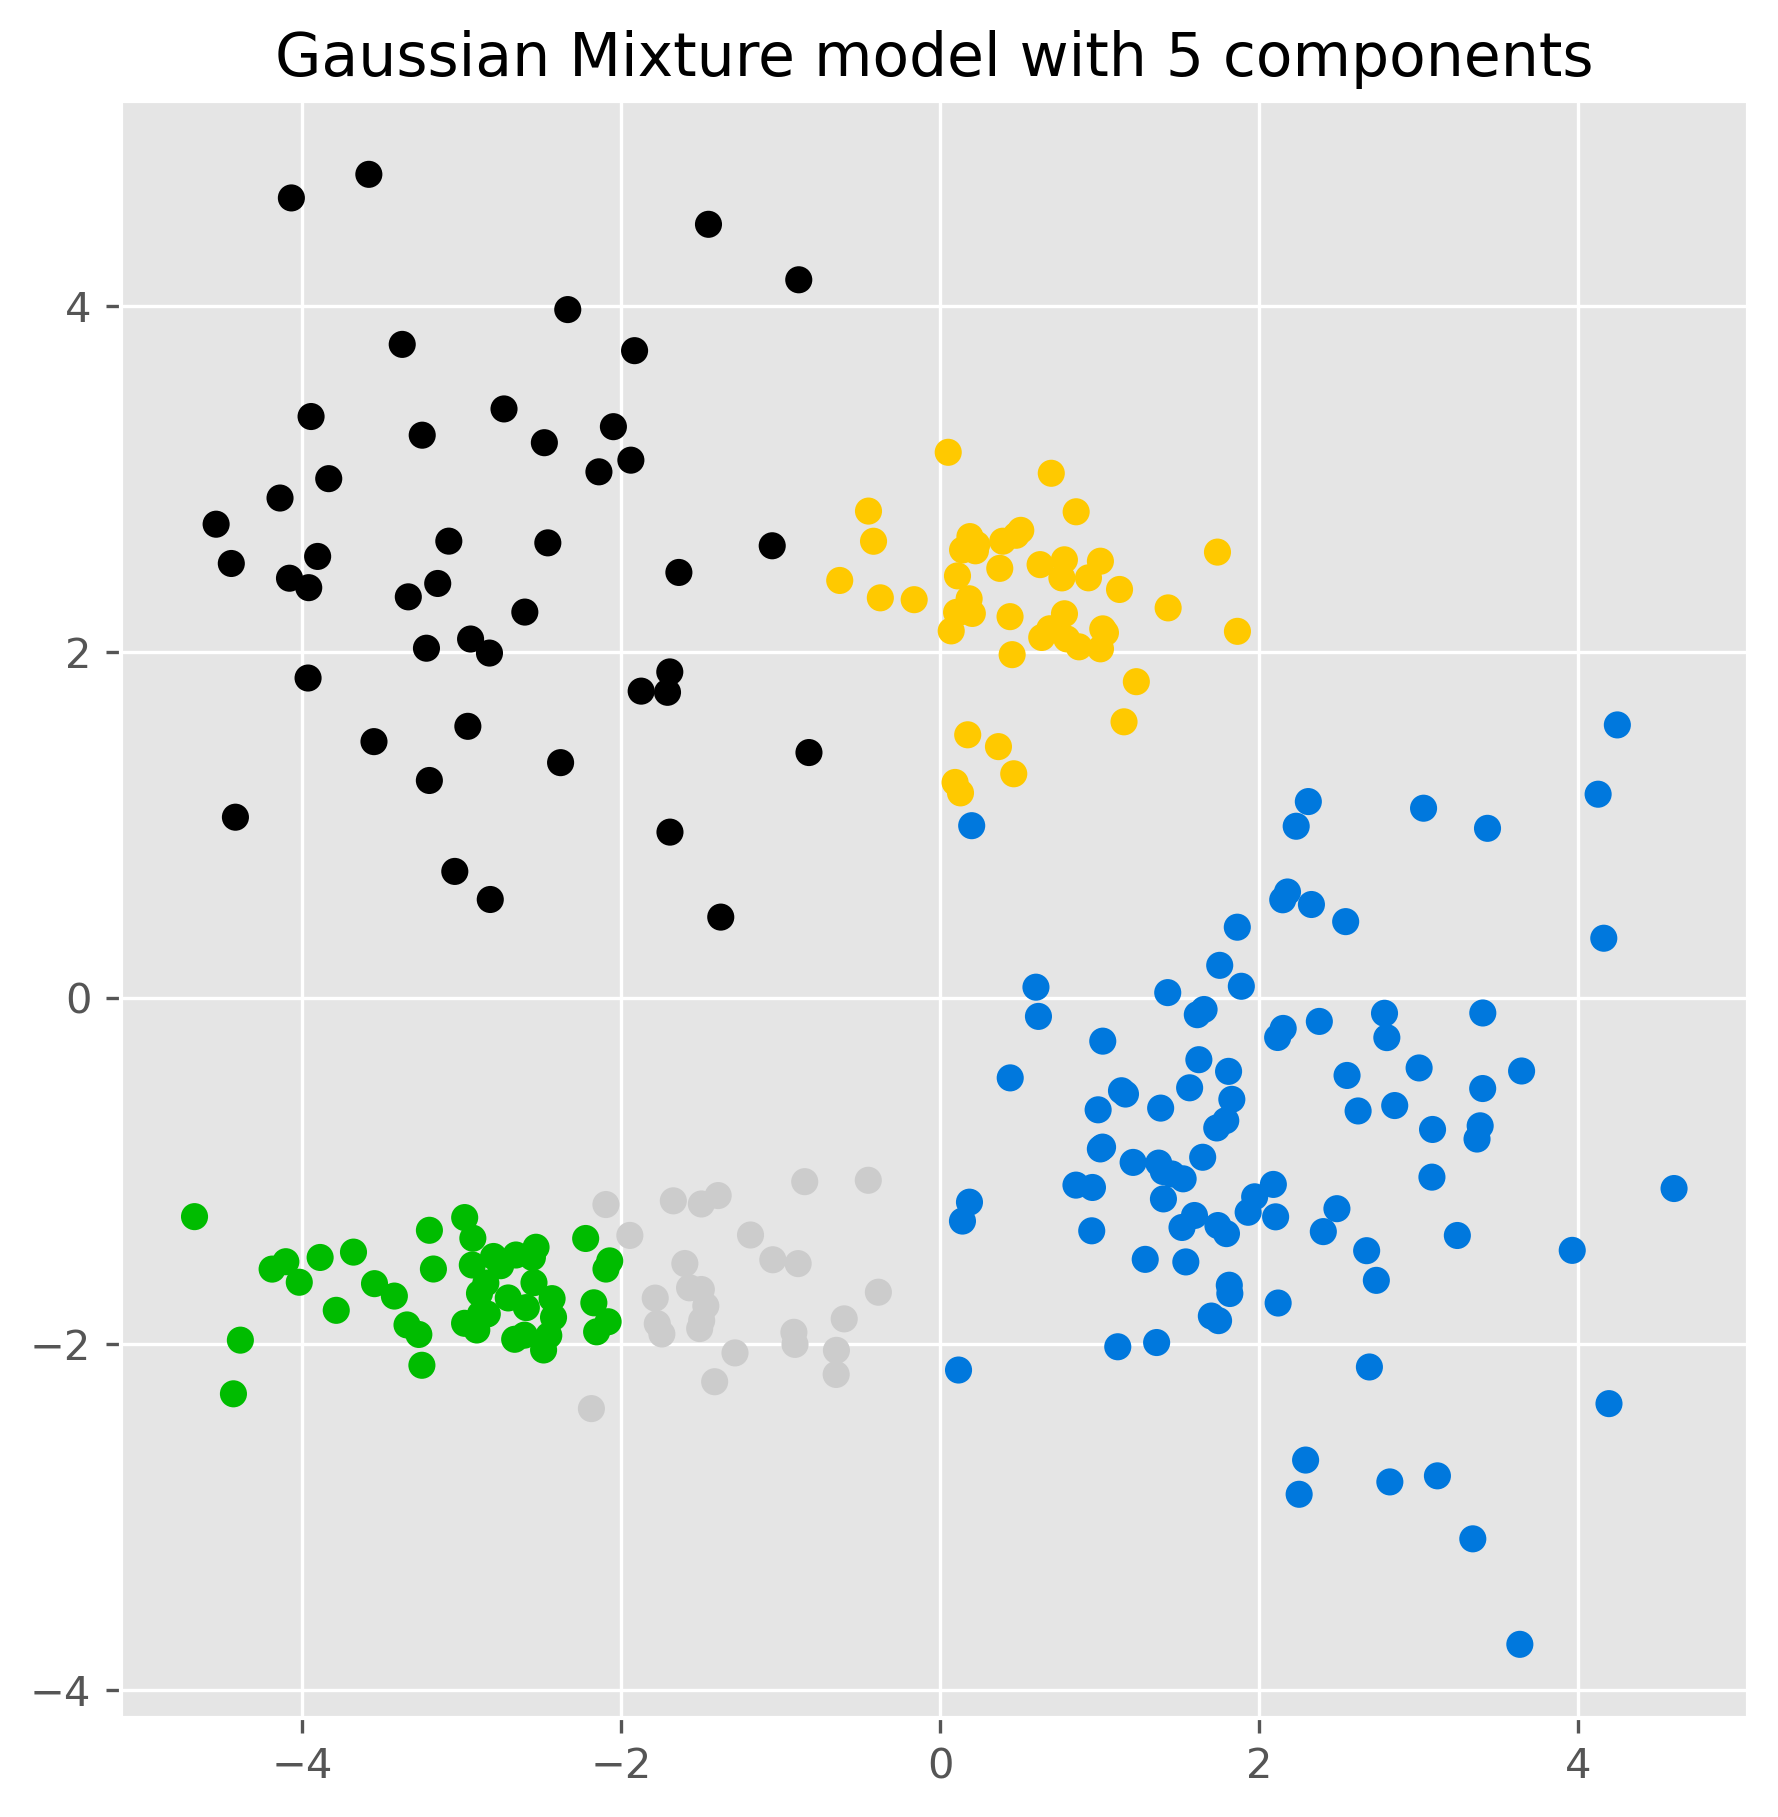

In [6]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

ax.scatter(data[:,0], data[:,1], c=labels, cmap="nipy_spectral")
ax.set_title("Gaussian Mixture model with 5 components")
plt.show()

The result may look similar to K-means at first glance, but conceptually something important has changed. The model is no longer just assigning points to the nearest center. Instead, it is fitting several Gaussian distributions to the data.

We can inspect the estimated component means:

In [7]:
gm.means_

array([[-2.80121071,  2.49623595],
       [ 2.08237568, -0.79412545],
       [-2.96321278, -1.69907782],
       [ 0.49887671,  2.26838731],
       [-1.43864991, -1.67923165]])

And we can also inspect the **probabilities** for the cluster membership, for instance for the last five elements in our data:

In [19]:
pd.DataFrame(gm.predict_proba(data[-5:]), columns = [f"cluster {i+1}" for i in range(5)])

,cluster 1,cluster 2,cluster 3,cluster 4,cluster 5
0,0.000117,0.000631,0.243636,1.626793e-21,0.755616
1,0.000075,0.000002,0.934538,1.678483e-28,0.065385
2,0.000227,0.004955,0.064392,1.869280e-18,0.930427
3,0.001274,0.000005,0.901200,3.493556e-25,0.097520
4,0.000033,0.000735,0.223215,3.389279e-24,0.776017


`gm.predict_proba()` returns, for each of the first five data points, a vector of probabilities indicating how strongly the model associates that point with each Gaussian component.

## Visualizing the Gaussian components

One nice aspect of GMM is that we can visualize the estimated distributions directly through ellipses derived from the covariance matrices.

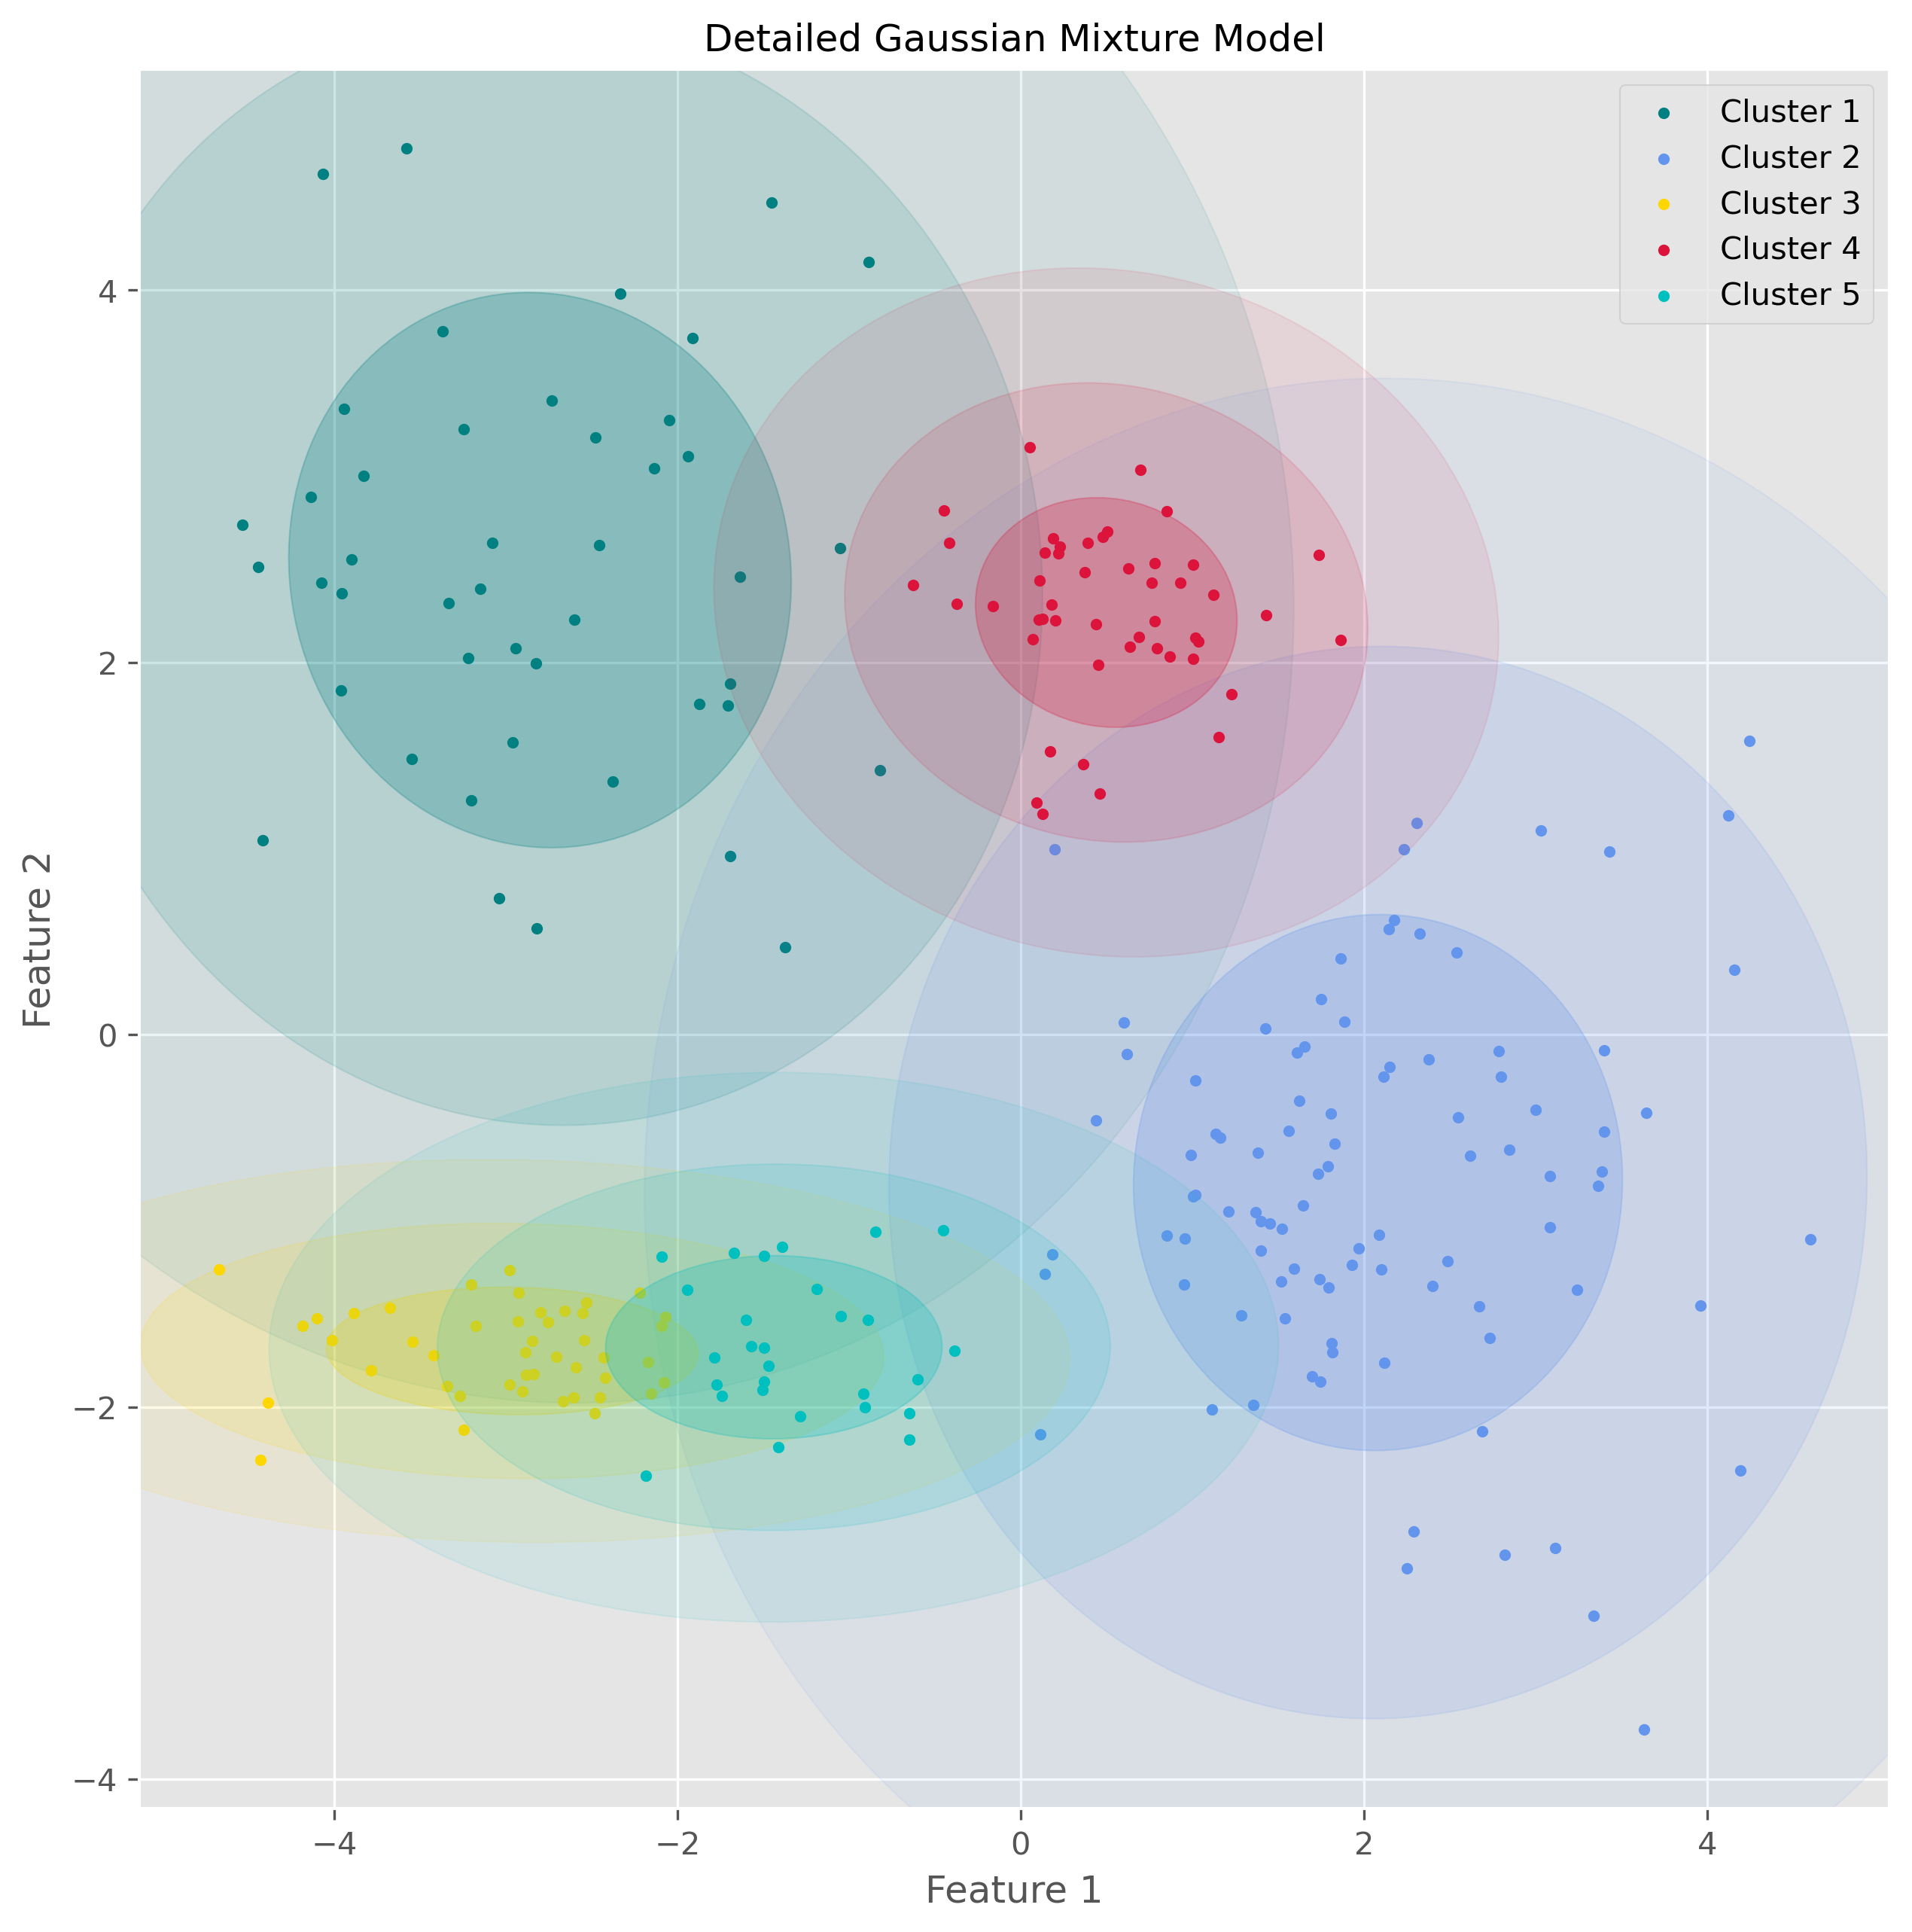

In [20]:
from matplotlib.patches import Ellipse
from scipy import linalg
import itertools

color_iter = itertools.cycle(['teal', 'cornflowerblue', 'gold', 'crimson', 'c'])

def plot_gmm(X, Y_, means, covariances, title):
    fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

    for i, (mean, covar, color) in enumerate(zip(means, covariances, color_iter)):
        if not np.any(Y_ == i):
            continue

        ax.scatter(X[Y_ == i, 0], X[Y_ == i, 1], s=10, color=color, label=f'Cluster {i+1}')

        v, w = linalg.eigh(covar)
        v = 2. * np.sqrt(2.) * np.sqrt(v)

        u = w[0] / linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180. * angle / np.pi

        for std_dev in range(1, 4):
            ell = Ellipse(mean, std_dev * v[0], std_dev * v[1], angle=180. + angle, color=color)
            ell.set_clip_box(ax.bbox)
            ell.set_alpha(0.25 / std_dev)
            ax.add_artist(ell)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    plt.legend()
    plt.show()

plot_gmm(data, gm.predict(data), gm.means_, gm.covariances_, "Detailed Gaussian Mixture Model")

This visualization makes the underlying idea of GMM much clearer: the algorithm is not just drawing boundaries between groups, but modeling the data as overlapping probability clouds.

## Strengths and weaknesses of GMM

GMM has several important advantages.

It is more flexible than K-means because it can model clusters with different shapes, sizes, and orientations. It also provides soft assignments, which can be very useful when cluster boundaries are unclear. And because it is probabilistic, it often gives a more nuanced description of the data.

At the same time, GMM also has limitations. Like K-means, it requires us to specify the number of components in advance. It is usually more computationally demanding than K-means, and it depends more strongly on the assumption that clusters are reasonably well described by Gaussian distributions. If the true data structure is very non-Gaussian, the model may still impose Gaussian components in a way that is not very meaningful.

So GMM is powerful, but it is not simply “better than K-means.” It is better suited for some situations and less suitable for others.

---

## Hierarchical clustering

Another important family of clustering methods is **hierarchical clustering**.

Instead of directly dividing the data into one fixed set of clusters, hierarchical clustering builds a **hierarchy of nested groups**. This means that it does not just tell us one possible clustering, but gives us a whole tree-like structure showing how small groups merge into larger ones.

This is especially useful when we do not know in advance how many clusters we want, or when we want to explore the data at different levels of granularity.

## Agglomerative clustering

The most common version is **agglomerative hierarchical clustering**, a bottom-up method.

The basic idea is simple:

1. Start with every data point as its own cluster.
2. Repeatedly merge the two most similar clusters.
3. Continue until all points have been merged into one large hierarchy.

To make this work, we need two ingredients:

* a way to measure the **distance between data points**,
* and a rule for measuring the **distance between clusters**.

There are different linkage methods for this second step. In this section, we focus on **Ward linkage**, which tries to merge clusters in a way that keeps the increase in within-cluster variance as small as possible.

## How Ward clustering works

Ward’s method favors merges that create relatively compact clusters. In that sense, it has some similarity to K-means, because it also prefers clusters that are internally coherent. But unlike K-means, it does not require us to specify the number of clusters at the start.

Using scikit-learn, we can fit agglomerative clustering as follows:

In [21]:
from sklearn.cluster import AgglomerativeClustering

ward = AgglomerativeClustering(
    linkage="ward",
    n_clusters=None,
    distance_threshold=10.0
).fit(data)

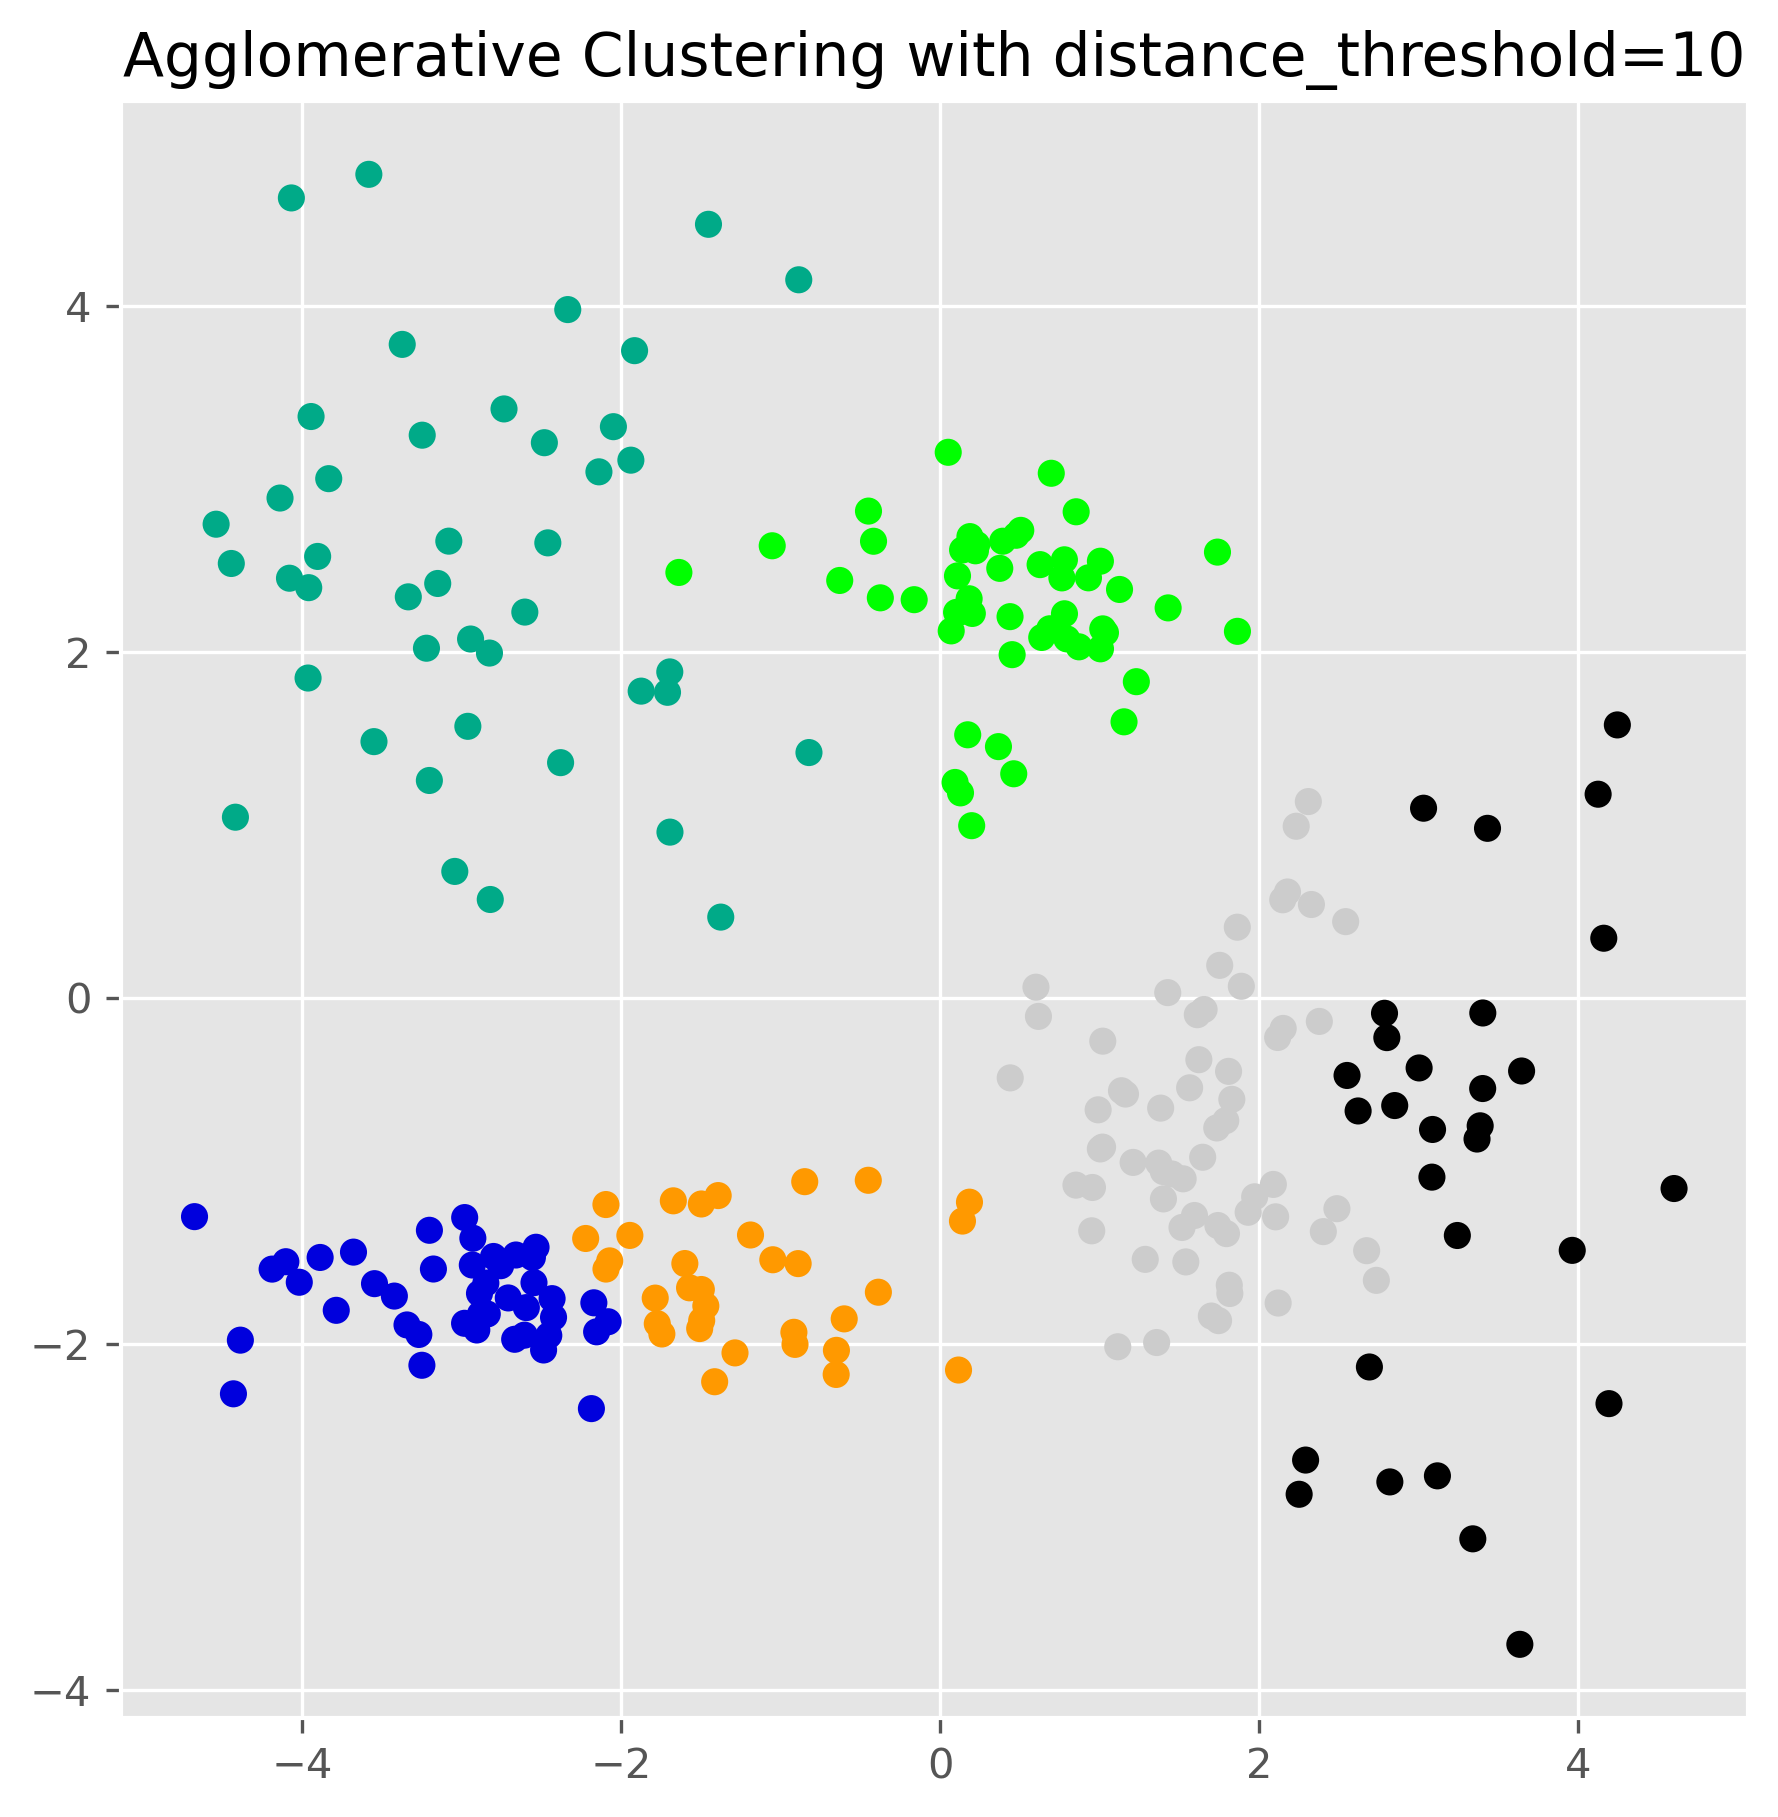

In [22]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

ax.scatter(data[:, 0], data[:, 1], c=ward.labels_, cmap="nipy_spectral")
ax.set_title("Agglomerative Clustering with distance_threshold=10")
plt.show()

This produces one clustering result, but the real strength of hierarchical clustering lies in the fact that it has built a full hierarchy in the background.

## The dendrogram

The hierarchy can be visualized using a **dendrogram**. This is a tree-like plot that shows which clusters were merged and at what distance.
A low merge in the dendrogram means that two clusters were very similar. A high merge means that the algorithm had to go much further to combine them.  
Here is a helper function to plot a dendrogram for the fitted model:


In [24]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    n_samples = len(model.labels_)

    counts = np.zeros(model.children_.shape[0])
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

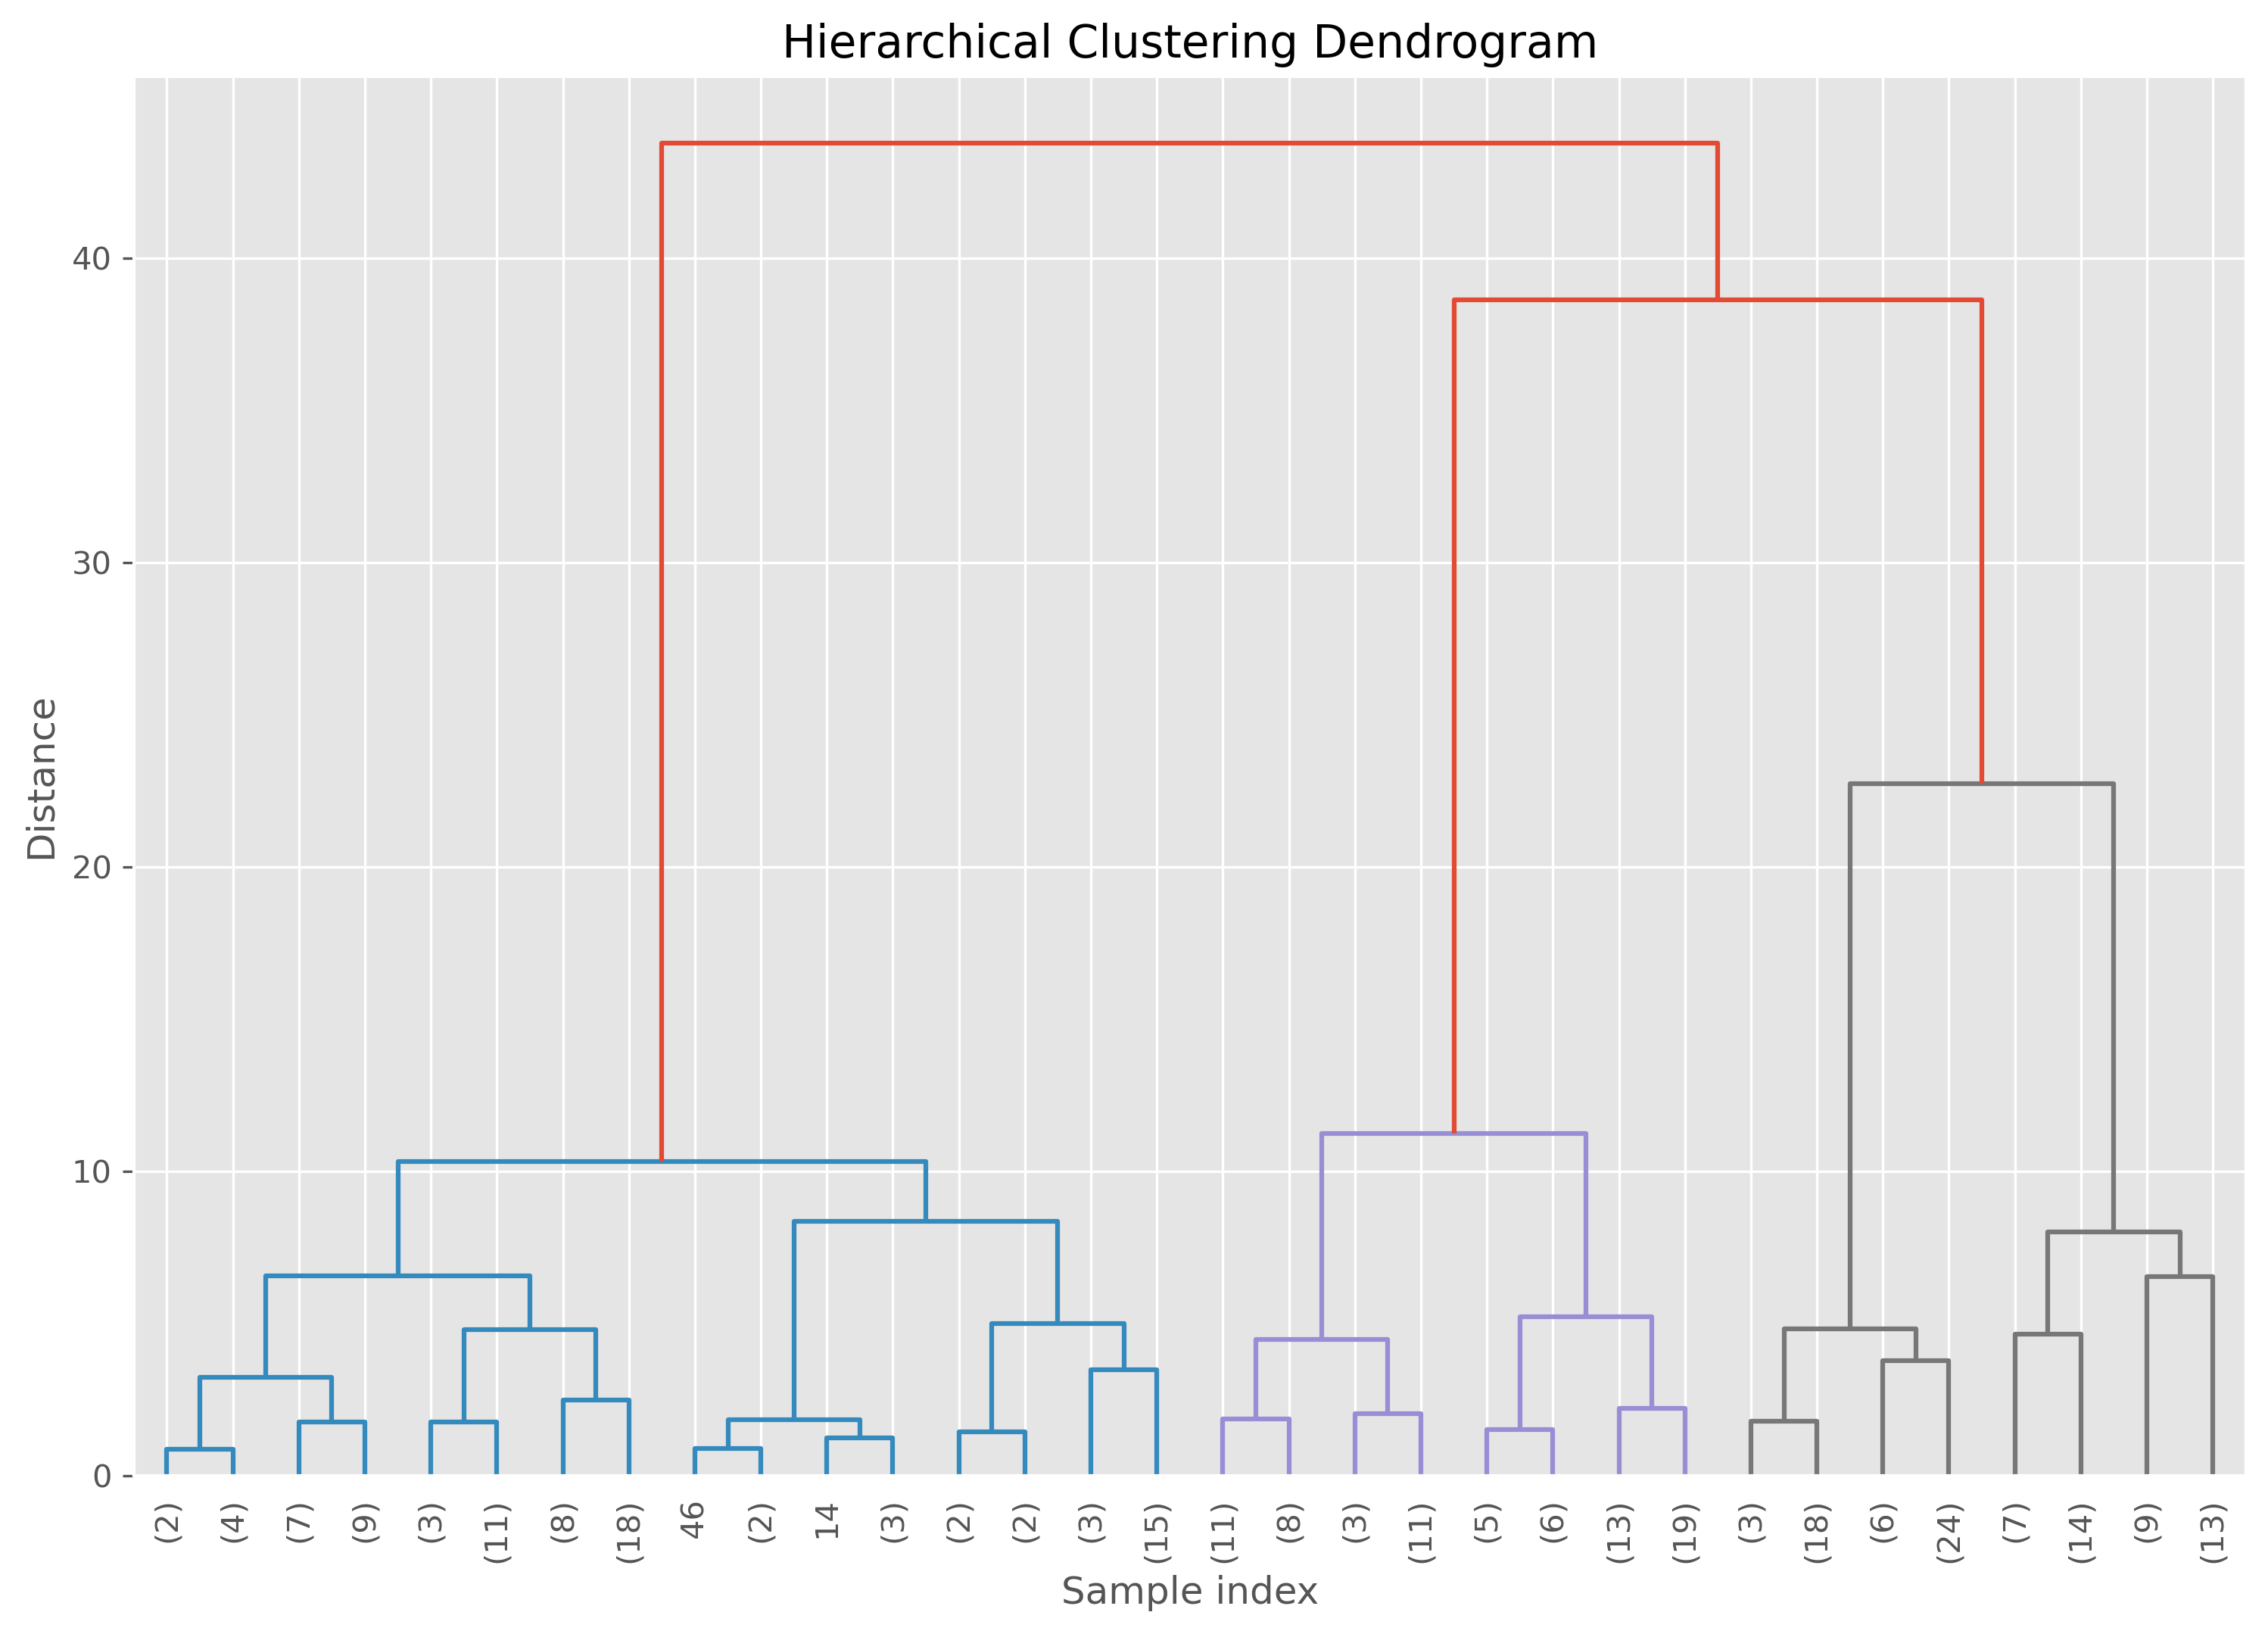

In [27]:
plt.figure(figsize=(12, 8), dpi=300)
plot_dendrogram(
    ward,
    leaf_rotation=90,
    leaf_font_size=10,
    truncate_mode="level",
    p=4
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

The important practical idea is this: **cutting** the dendrogram at different heights gives different numbers of clusters. A high cut produces only a few broad clusters. A low cut produces many smaller ones.  
So hierarchical clustering does not eliminate the question of how many clusters to use. But it does postpone that decision and allows us to explore several possibilities.

## Varying the distance threshold

In scikit-learn’s agglomerative clustering, one way to control the final clustering is through the `distance_threshold`.

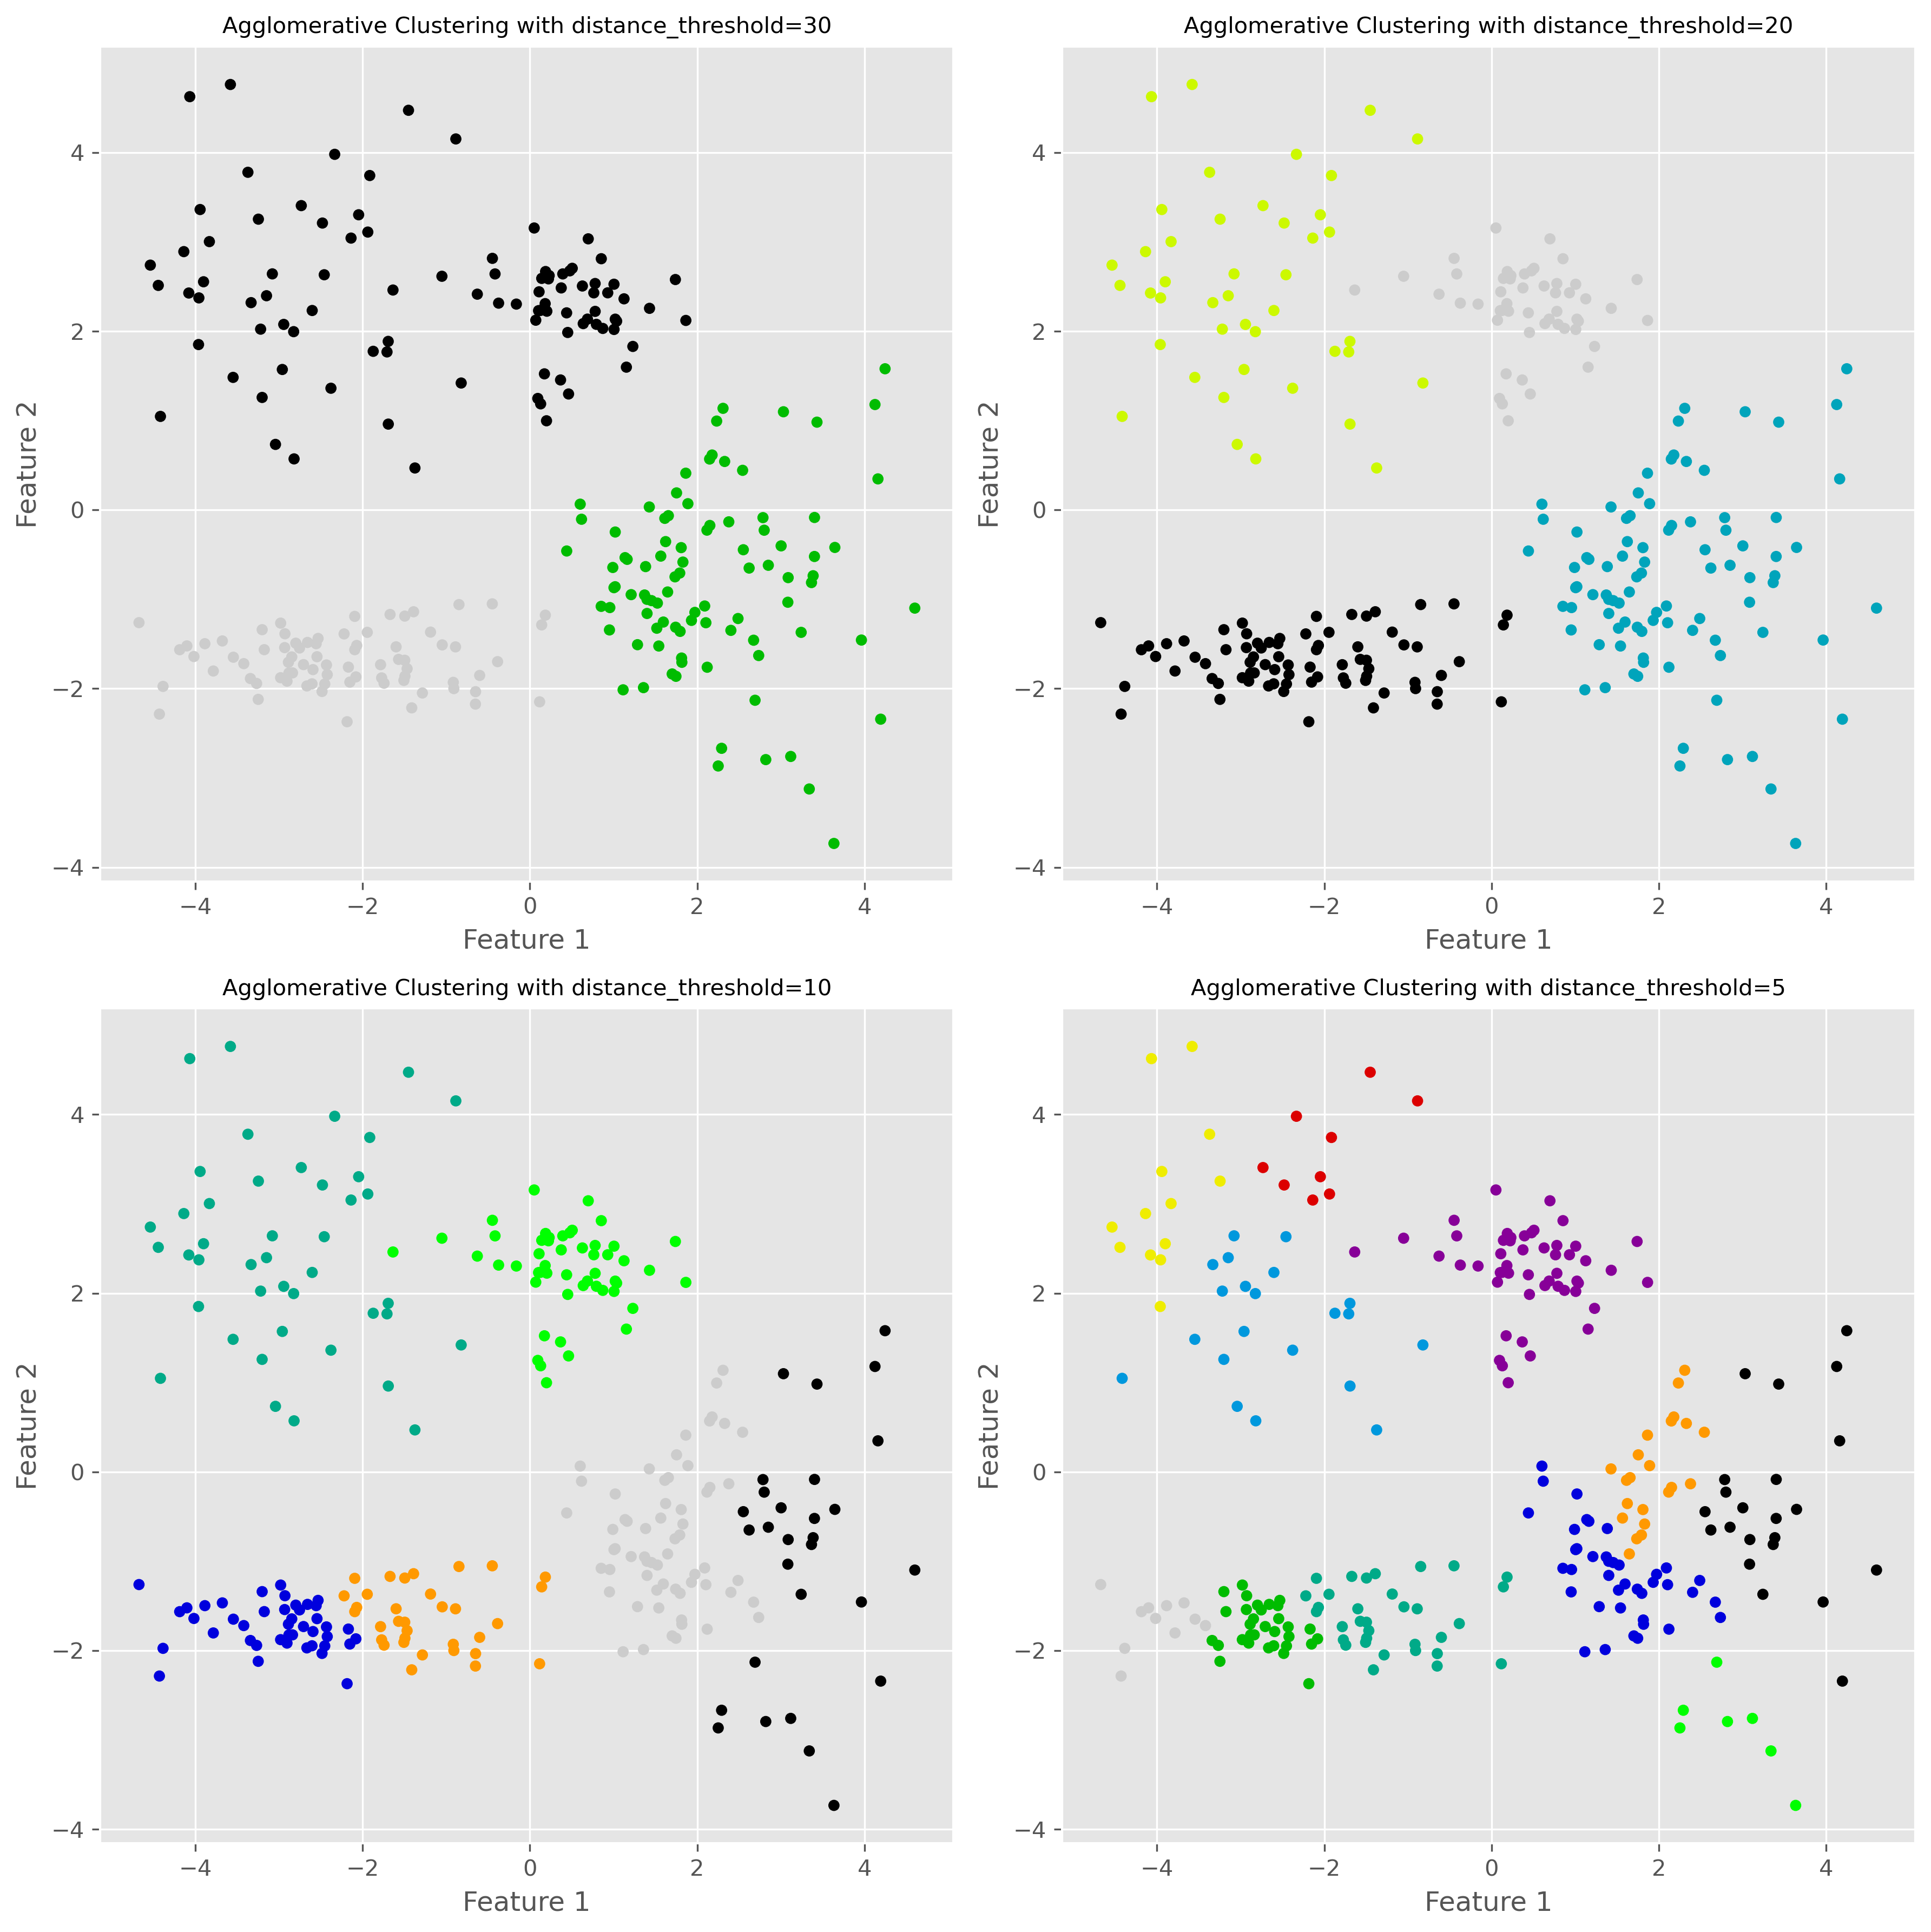

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=300)

distance_thresholds = [30, 20, 10, 5]
for i, distance_threshold in enumerate(distance_thresholds):
    ward = AgglomerativeClustering(
        linkage="ward",
        n_clusters=None,
        distance_threshold=distance_threshold
    )
    ward.fit(data)

    ax = axes[i // 2, i % 2]
    labels = ward.labels_
    ax.scatter(data[:, 0], data[:, 1], c=labels, cmap="nipy_spectral", s=20)
    ax.set_title(f"Agglomerative Clustering with distance_threshold={distance_threshold}", fontsize=10)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

A lower distance threshold cuts the hierarchy closer to the individual points, leading to more clusters. A higher threshold merges more groups together, leading to fewer clusters.

## Strengths and weaknesses of hierarchical clustering

Hierarchical clustering has several attractive features. Most importantly, it gives us a multi-scale view of the data instead of just one partition. The dendrogram can also be very informative, especially in exploratory work.

Another advantage is that we do not have to fix the number of clusters at the start. We can inspect the hierarchy first and then decide which level of grouping is useful.

However, hierarchical clustering also has clear disadvantages. It can become computationally expensive for large datasets. Early merge decisions cannot be undone later, which means that a questionable early merge can influence the whole hierarchy. And although we do not need to decide on the number of clusters immediately, we still need some criterion for deciding where to cut the tree.

---

## Two more important density-based methods: OPTICS and HDBSCAN

Before we move on to a broader comparison, it is worth briefly mentioning two further clustering methods that are especially relevant when working with data of **varying density**: **OPTICS** and **HDBSCAN**.

### OPTICS

**OPTICS** stands for *Ordering Points To Identify the Clustering Structure*. Like DBSCAN, it is a **density-based** clustering method. But instead of committing immediately to one fixed neighborhood radius `eps`, OPTICS explores the data across a range of density levels and records how points are connected to one another.

This makes OPTICS especially useful when clusters have different densities. In situations where DBSCAN struggles because one single `eps` value is too small for one cluster and too large for another, OPTICS can often give a more informative picture of the clustering structure.  
Conceptually, OPTICS is closely related to DBSCAN, but more flexible. The trade-off is that it is also somewhat more complex to understand and interpret.

### HDBSCAN

**HDBSCAN** stands for *Hierarchical Density-Based Spatial Clustering of Applications with Noise*. It can be seen as an extension of DBSCAN that combines **density-based clustering** with a **hierarchical view** of the data.

Instead of fixing one global density threshold, HDBSCAN builds a hierarchy of density-connected clusters and then extracts the most stable ones. This makes it particularly attractive when the dataset contains clusters with very different densities or when we want a method that is more adaptive than DBSCAN.

Like DBSCAN, HDBSCAN can also identify noise points. In practice, it is often considered one of the most powerful off-the-shelf clustering methods for messy real-world data—especially when clusters are irregularly shaped and vary in density.
The downside is that, like many more flexible methods, it is somewhat less intuitive than K-means and usually not the first clustering algorithm people learn.

---

## Comparing clustering approaches

At this point, we have seen six different clustering methods across the two clustering chapters. These methods follow sometimes very different conceptual routes so that they naturally differ in what they consider to be a cluster.

**K-means** sees clusters as groups around centroids. It works best when clusters are compact, roughly spherical, and of similar size.

**DBSCAN** sees clusters as dense regions separated by sparse regions. It is good at finding irregularly shaped clusters and identifying noise, but struggles when clusters have very different densities.

**Gaussian Mixture Models (GMMs)** model clusters as Gaussian probability distributions. They are more flexible than K-means and allow soft assignments, but assume that Gaussian components are a meaningful description of the data.

**Hierarchical clustering** builds a hierarchy of nested groups. It is especially useful when we want to explore grouping at multiple levels, but it can become computationally expensive on larger datasets.

**OPTICS** is closely related to DBSCAN, but instead of relying on a single fixed density threshold, it explores the data across a range of density levels. This makes it useful when different clusters have different densities.

**HDBSCAN** combines density-based clustering with a hierarchical view and is often particularly effective on real-world datasets with irregular cluster shapes, noise, and varying densities.

None of these algorithms is universally best. The right choice depends on the geometry of the data, the amount of noise, whether the number of clusters is roughly known, whether densities vary strongly, and what we ultimately want to do with the clustering result.

## A compact visual comparison

To conclude, it is helpful to compare different clustering algorithms on several kinds of datasets.

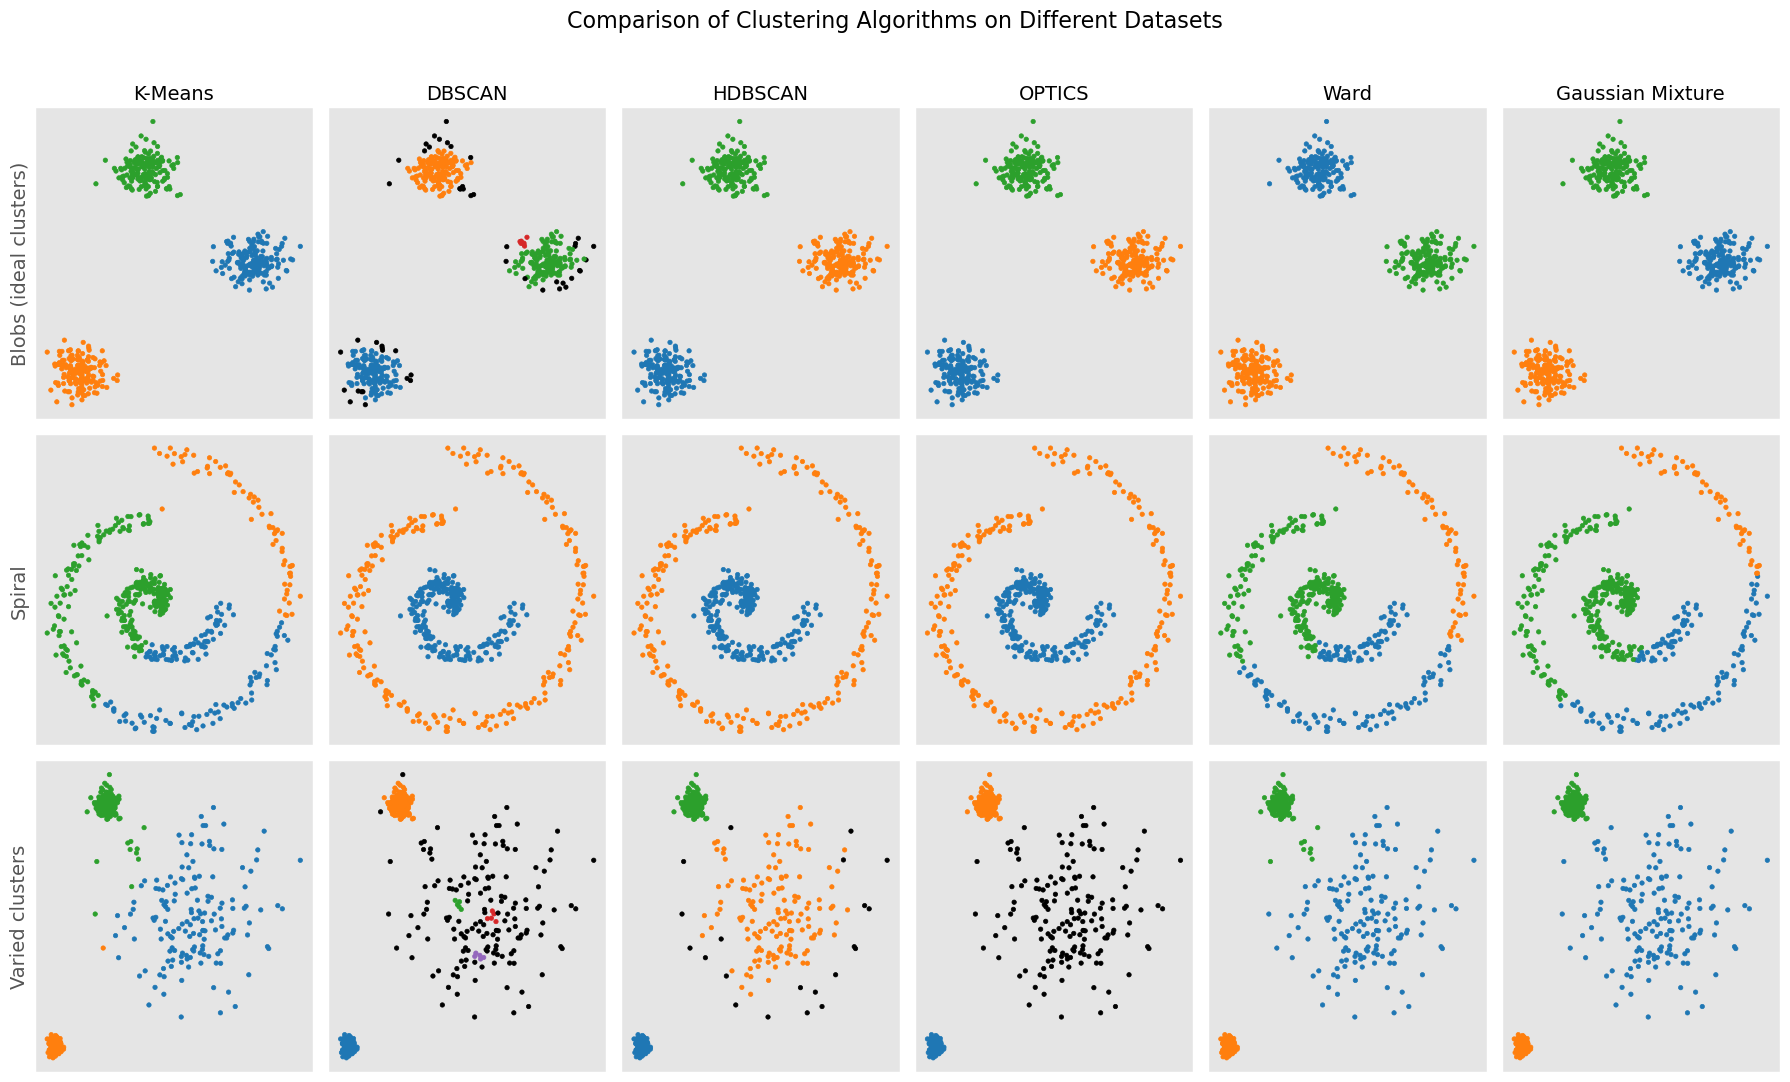

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, OPTICS, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Seed for reproducibility
random_state = 42
np.random.seed(random_state)

# Generate datasets
n_samples = 500

# 1. Ideal clusters (blobs)
X_blobs, _ = make_blobs(n_samples=n_samples, centers=3, cluster_std=1.0, random_state=random_state)

# 2. Spiral data
theta = np.concatenate([
    np.linspace(0, 2.0 * np.pi, int(n_samples/2)),
    np.linspace(2.5 * np.pi, 4.5 * np.pi, int(n_samples/2))
])
r = theta.copy() / 5
noise = np.random.RandomState(random_state).normal(scale=0.1, size=(n_samples, 2))
X_spiral = np.vstack((r * np.cos(theta), r * np.sin(theta))).T + noise

# 3. Varied clusters with pronounced density fluctuations
X_varied, _ = make_blobs(
    n_samples=n_samples,
    centers=3,
    cluster_std=[0.5, 3.0, 0.3],
    random_state=random_state
)

# 4. No structure
X_no_structure = np.random.uniform(-1, 1, size=(n_samples, 2))

datasets = [
    (X_blobs, "Blobs (ideal clusters)"),
    (X_spiral, "Spiral"),
    (X_varied, "Varied clusters"),
    #(X_no_structure, "No structure")
]

# Define clustering algorithms
algorithms = [
    ("K-Means", KMeans(n_clusters=3, random_state=random_state)),
    ("DBSCAN", DBSCAN(eps=0.5, min_samples=5)),
    ("HDBSCAN", HDBSCAN(min_cluster_size=20, min_samples=5, copy=True)),
    ("OPTICS", OPTICS(min_samples=5, xi=0.5, min_cluster_size=0.05)),
    ("Ward", AgglomerativeClustering(n_clusters=3, linkage="ward")),
    ("Gaussian Mixture", GaussianMixture(n_components=3, covariance_type="full", random_state=random_state))
]

# Create overview plot
fig, axes = plt.subplots(len(datasets), len(algorithms), figsize=(18, 11))
for row, (X, title) in enumerate(datasets):
    for col, (name, algo) in enumerate(algorithms):
        ax = axes[row, col]
        # Fit and predict
        if hasattr(algo, "fit_predict"):
            labels = algo.fit_predict(X)
        else:
            model = algo.fit(X)
            labels = model.predict(X)
        
        # Color mapping
        unique_labels = np.unique(labels)
        color_cycle = cycle(plt.cm.tab10.colors)
        cluster_colors = {
            lab: (0, 0, 0, 1) if lab == -1 else next(color_cycle)
            for lab in unique_labels
        }
        colors = [cluster_colors[lab] for lab in labels]
        
        ax.scatter(X[:, 0], X[:, 1], s=10, c=colors)
        if row == 0:
            ax.set_title(name, fontsize=14)
        if col == 0:
            ax.set_ylabel(title, fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Comparison of Clustering Algorithms on Different Datasets", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Continue learning

There are many more clustering methods beyond the ones introduced here. A good next step is to further explore more modern methods such as **OPTICS**, **spectral clustering**, or **HDBSCAN**, each of which addresses particular limitations of the methods discussed so far.

For further reading, the scikit-learn clustering module is an excellent place to explore additional examples and practical comparisons:

* [Scikit-learn clustering documentation](https://scikit-learn.org/stable/modules/clustering.html)

There are many books, tutorials, and articles on various clustering techniques. Here is just one more recent scientific review article on different clustering techniques:

- "A review of clustering techniques and developments" by Amit Saxena and Mukesh Prasad and Akshansh Gupta and Neha Bharill and Om Prakash Patel and Aruna Tiwari and Meng Joo Er and Weiping Ding and Chin-Teng Lin, 2017, Neurocomputing, Vol.267, https://doi.org/10.1016/j.neucom.2017.06.053 {cite}`saxena2017review`
